# Project - 2 : Unemployment Analysis with Python

## Objective
Perform exploratory data analysis on unemployment data to uncover regional and temporal trends, with a focus on the impact of the COVID-19 pandemic on unemployment rates in India.
## Tech Stack
Python, pandas, matplotlib, seaborn, Jupyter Notebook


### Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set(font_scale=1.1)

%matplotlib inline

### Load Dataset

In [2]:
df = pd.read_csv("Unemployment in India.csv")

### Data Cleaning

In [4]:
print(df.columns)

print(df["Date"].head(10))

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')
0     31-05-2019
1     30-06-2019
2     31-07-2019
3     31-08-2019
4     30-09-2019
5     31-10-2019
6     30-11-2019
7     31-12-2019
8     31-01-2020
9     29-02-2020
Name: Date, dtype: object


In [5]:
df.columns = df.columns.str.strip()

df["Date"] = pd.to_datetime(
    df["Date"].astype(str).str.strip(),
    dayfirst=True
)

In [6]:
# Remove unnecessary spaces from column names
df.columns = df.columns.str.strip()

# Convert Date column
df["Date"] = pd.to_datetime(df["Date"], format="%d-%m-%Y")

# Check first rows
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural


### Dataset Information

In [7]:
print("Shape :", df.shape)

print("\nColumns")
print(df.columns)

print("\nData Types")
print(df.dtypes)

print("\nMissing Values")
print(df.isnull().sum())

Shape : (768, 7)

Columns
Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')

Data Types
Region                                             object
Date                                       datetime64[ns]
Frequency                                          object
Estimated Unemployment Rate (%)                   float64
Estimated Employed                                float64
Estimated Labour Participation Rate (%)           float64
Area                                               object
dtype: object

Missing Values
Region                                     28
Date                                       28
Frequency                                  28
Estimated Unemployment Rate (%)            28
Estimated Employed                         28
Estimated Labour Participation Rate (%)    28
Area                                       28
dtype: int64


### Remove Missing Values

In [8]:
df = df.dropna()

print(df.shape)

(740, 7)


In [9]:
df.describe()

,Date,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740,740.000000,7.400000e+02,740.000000
mean,2019-12-12 18:36:58.378378496,11.787946,7.204460e+06,42.630122
min,2019-05-31 00:00:00,0.000000,4.942000e+04,13.330000
25%,2019-08-31 00:00:00,4.657500,1.190404e+06,38.062500
50%,2019-11-30 00:00:00,8.350000,4.744178e+06,41.160000
75%,2020-03-31 00:00:00,15.887500,1.127549e+07,45.505000
max,2020-06-30 00:00:00,76.740000,4.577751e+07,72.570000
std,NaN,10.721298,8.087988e+06,8.111094


#### Observation

The dataset contains monthly unemployment statistics for Indian states. After cleaning, missing values are removed and the Date column is converted into datetime format for time-series analysis.

### Add Month and Year Columns

In [10]:
df["Month"] = df["Date"].dt.month_name()
df["Year"] = df["Date"].dt.year

### Region-wise Average Unemployment Rate

C:\Users\ARGHYADIP GHOSH\AppData\Local\Temp\ipykernel_9560\177730744.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


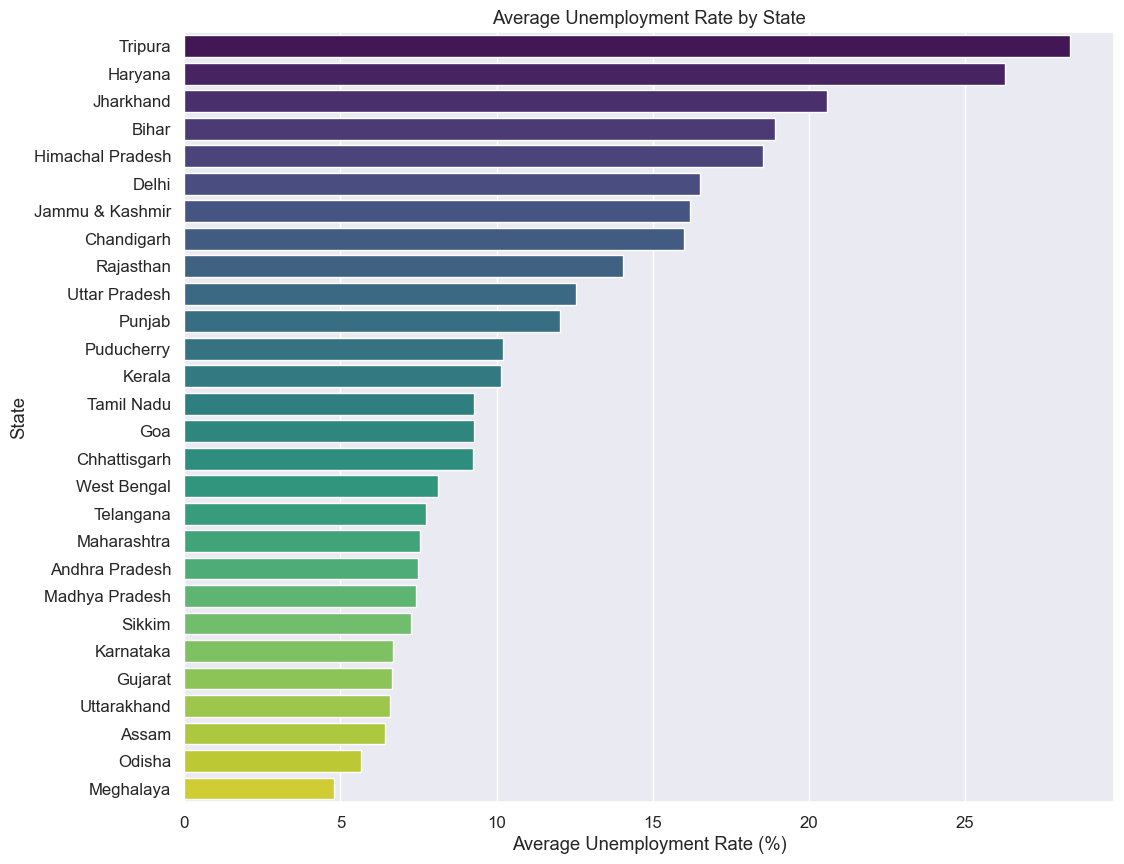

In [11]:
region_avg = (df.groupby("Region")["Estimated Unemployment Rate (%)"]
                .mean()
                .sort_values(ascending=False))

plt.figure(figsize=(12,10))

sns.barplot(
    x=region_avg.values,
    y=region_avg.index,
    palette="viridis"
)

plt.title("Average Unemployment Rate by State")
plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("State")

plt.show()

##### Observation :
- Tripura has one of the highest unemployment rates.
- Meghalaya and Assam show comparatively lower unemployment.
- There is significant regional variation across India.

### Top 10 States with Highest Average Unemployment

C:\Users\ARGHYADIP GHOSH\AppData\Local\Temp\ipykernel_9560\1777636338.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


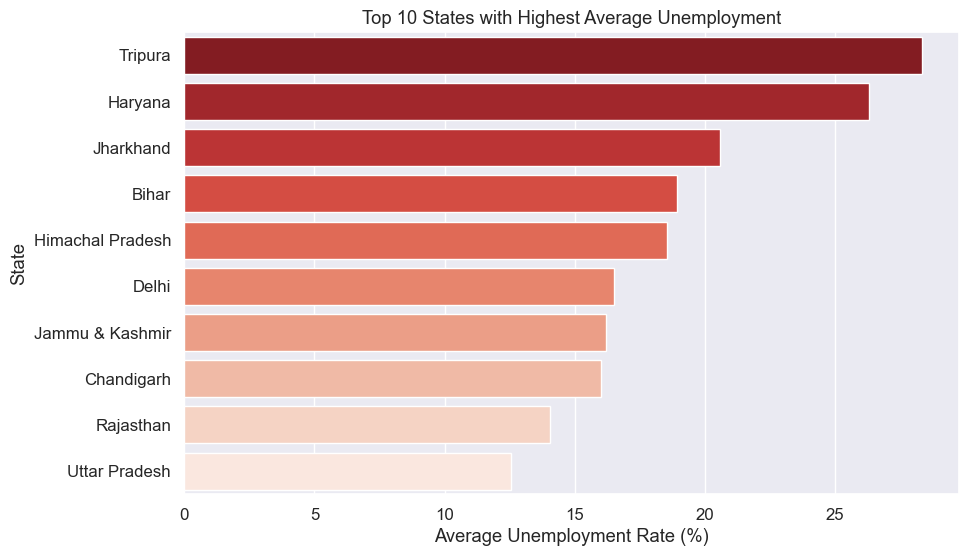

In [12]:
top10 = region_avg.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top10.values,
    y=top10.index,
    palette="Reds_r"
)

plt.title("Top 10 States with Highest Average Unemployment")
plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("State")

plt.show()

##### Observation :

The top 10 states consistently experienced higher unemployment throughout the observation period.

### Month-wise Average Unemployment Trend

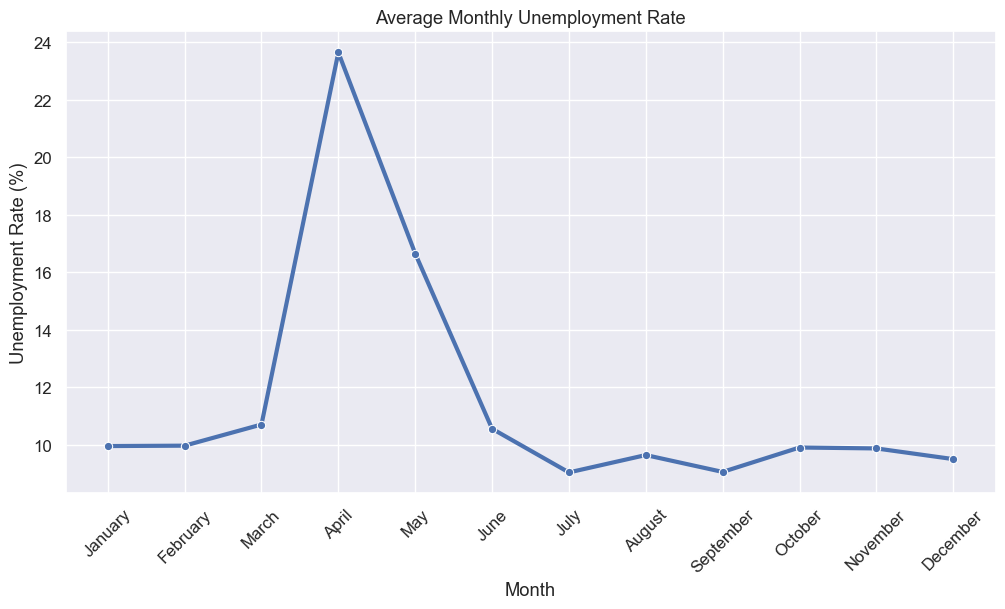

In [13]:
month_order = [
'January','February','March','April','May','June',
'July','August','September','October','November','December'
]

monthly = (df.groupby("Month")["Estimated Unemployment Rate (%)"]
             .mean()
             .reindex(month_order))

plt.figure(figsize=(12,6))

sns.lineplot(
    x=monthly.index,
    y=monthly.values,
    marker="o",
    linewidth=3
)

plt.xticks(rotation=45)

plt.title("Average Monthly Unemployment Rate")

plt.xlabel("Month")
plt.ylabel("Unemployment Rate (%)")

plt.show()

##### Observation :
- April and May exhibit the sharpest increase.
- These months correspond to the nationwide COVID-19 lockdown.

### Time Series Analysis (Top 3 Major States)

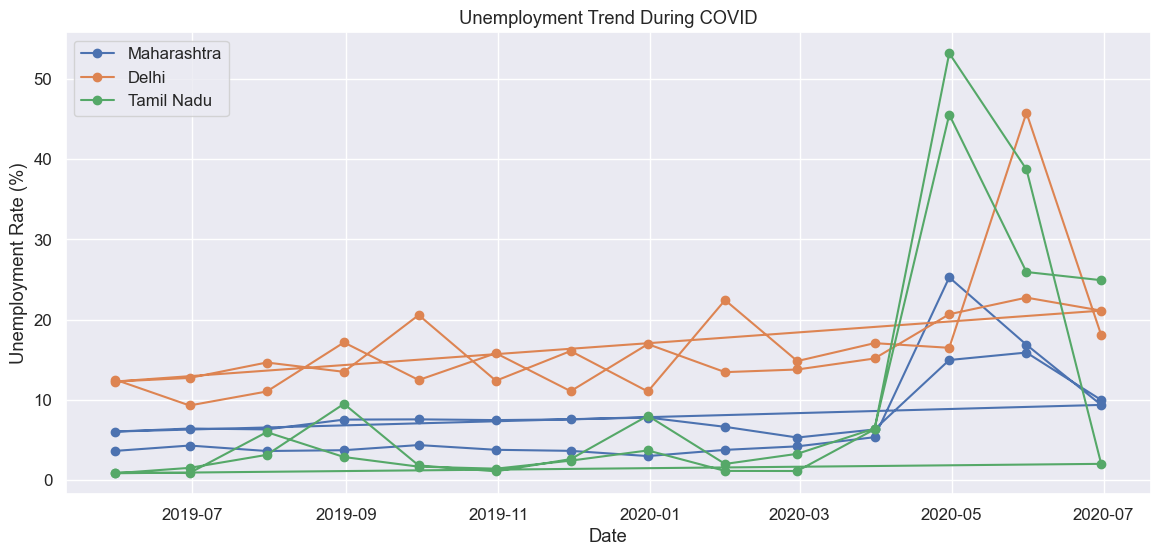

In [14]:
states = ["Maharashtra","Delhi","Tamil Nadu"]

plt.figure(figsize=(14,6))

for state in states:
    
    temp = df[df["Region"]==state]
    
    plt.plot(
        temp["Date"],
        temp["Estimated Unemployment Rate (%)"],
        marker="o",
        label=state
    )

plt.legend()

plt.title("Unemployment Trend During COVID")

plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")

plt.show()

##### Observation :
- Delhi experienced the sharpest unemployment spike.
- Maharashtra showed a substantial increase during lockdown.
- Tamil Nadu recovered more gradually.

### Correlation Heatmap

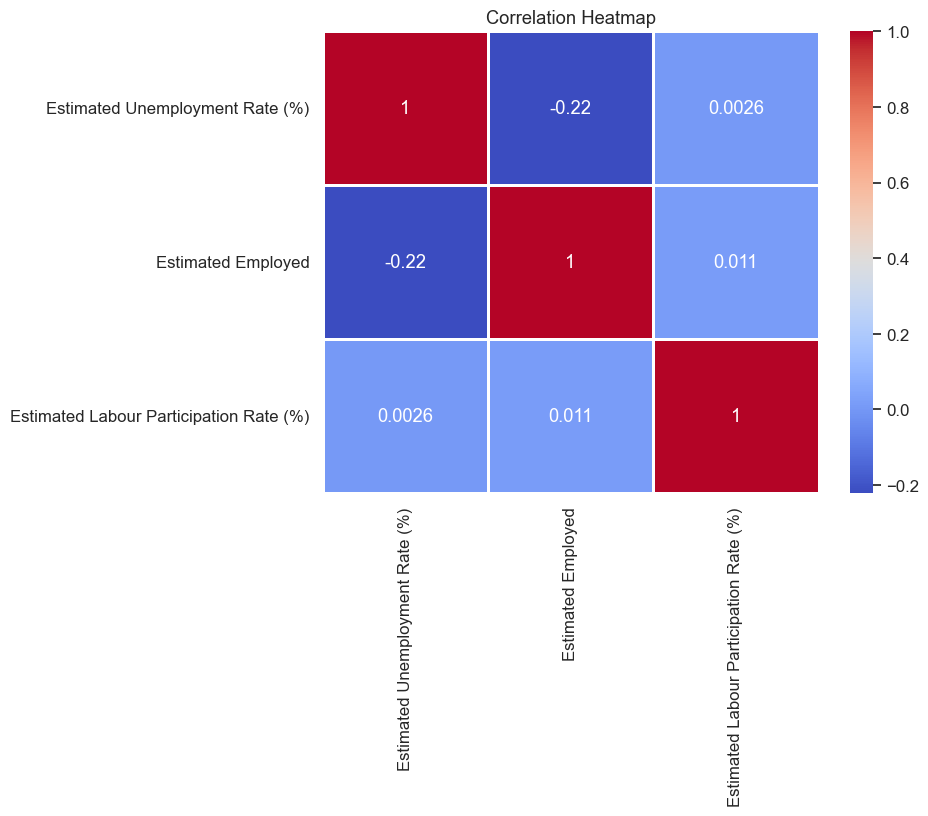

In [15]:
corr = df[[
    "Estimated Unemployment Rate (%)",
    "Estimated Employed",
    "Estimated Labour Participation Rate (%)"
]].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    linewidths=1
)

plt.title("Correlation Heatmap")

plt.show()

##### Observation :
- Employment is negatively correlated with unemployment.
- Labour participation has only a moderate relationship with unemployment.
- Higher employment generally corresponds to lower unemployment.

### COVID Impact Analysis
#### Pre-COVID vs Post-COVID

In [16]:
covid_date = pd.Timestamp("2020-03-25")

pre = df[df["Date"] < covid_date]

post = df[df["Date"] >= covid_date]

comparison = pd.DataFrame({
    "Pre-COVID":[pre["Estimated Unemployment Rate (%)"].mean()],
    "Post-COVID":[post["Estimated Unemployment Rate (%)"].mean()]
})

comparison

,Pre-COVID,Post-COVID
0,9.509534,17.774363


### Visualization

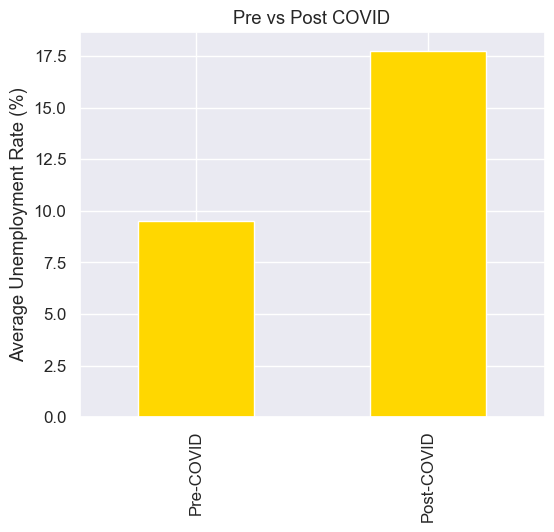

In [25]:
comparison.T.plot(
    kind="bar",
    figsize=(6,5),
    legend=False,
    color=["gold"]
)

plt.ylabel("Average Unemployment Rate (%)")

plt.title("Pre vs Post COVID")

plt.show()

##### Observation
The average unemployment rate increased significantly after the nationwide lockdown, indicating the severe economic impact of COVID-19.

### Rural vs Urban Comparison

C:\Users\ARGHYADIP GHOSH\AppData\Local\Temp\ipykernel_9560\4107111832.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


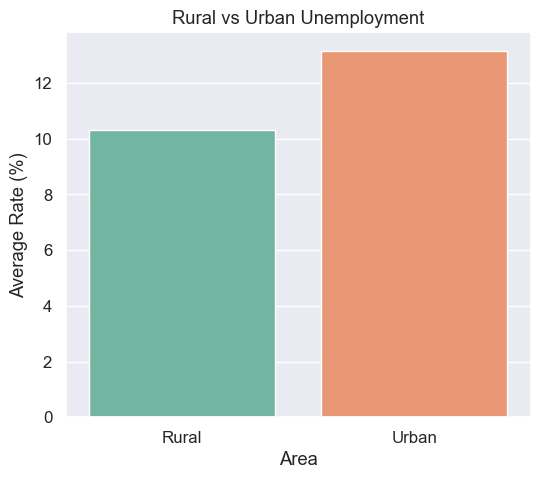

In [26]:
area = df.groupby("Area")["Estimated Unemployment Rate (%)"].mean()

plt.figure(figsize=(6,5))

sns.barplot(
    x=area.index,
    y=area.values,
    palette="Set2"
)

plt.title("Rural vs Urban Unemployment")

plt.ylabel("Average Rate (%)")

plt.show()

##### Observation

Urban unemployment tends to be higher because service-sector jobs were more heavily affected during lockdown periods.

### Distribution Plot

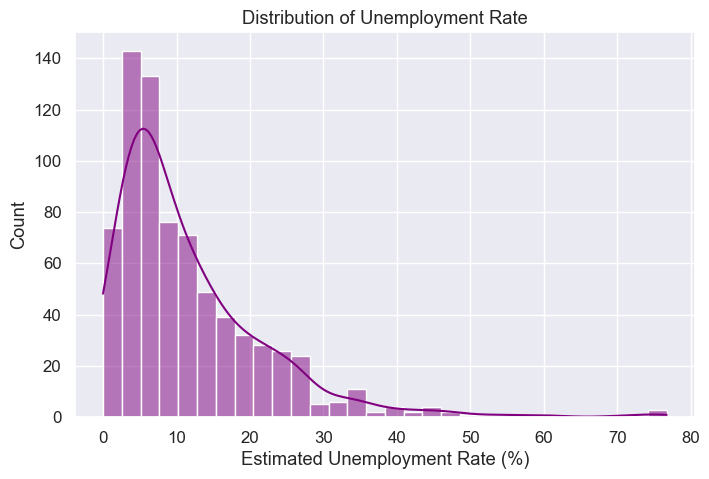

In [27]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Estimated Unemployment Rate (%)"],
    bins=30,
    kde=True,
    color="purple"
)

plt.title("Distribution of Unemployment Rate")

plt.show()

##### Observation

Most unemployment values lie between 5% and 15%, with several extreme spikes above 30%, reflecting pandemic-related disruptions.

### Boxplot (Outlier Detection)

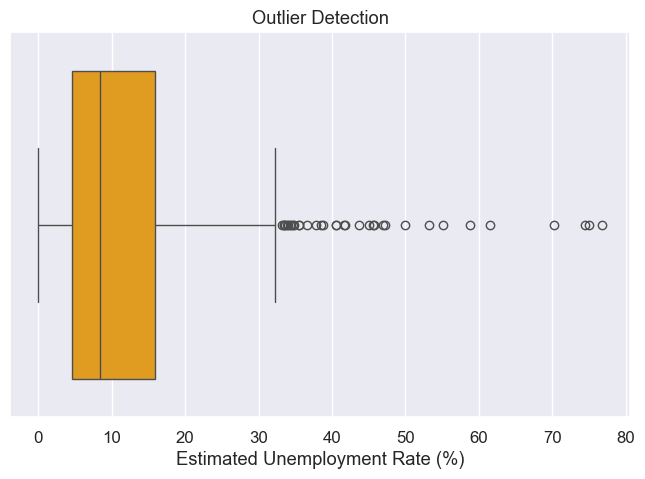

In [28]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["Estimated Unemployment Rate (%)"],
    color="orange"
)

plt.title("Outlier Detection")

plt.show()

##### Observation

Several extreme outliers exist due to the sudden unemployment surge during COVID-19.

## Final Conclusion

• The unemployment rate increased dramatically after March 2020 because of COVID-19.

• Delhi, Maharashtra and several other states experienced major unemployment spikes.

• Employment and unemployment show a strong negative relationship.

• Labour participation rate is only moderately correlated with unemployment.

• Urban regions generally experienced higher unemployment than rural regions.

• April–May 2020 recorded the highest unemployment across most states due to nationwide lockdowns.

• The analysis demonstrates the significant economic impact of the COVID-19 pandemic on India's labour market.